# Step 1: Formulate Research Questions

How do advertising budget across Tv, Radio, Newspaper, influence the prodect sales?

## Variables
- Independent Variables:
    - TV
    - Radio
    - Newspaper
- Dependent Variables:
    - Sales

# Step 2: Data Cleaning

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
    
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [4]:
df = pd.read_csv("advertising_dataset.csv")
df 

,TV,Radio,Newspaper,Sales
0,164.64,15.59,40.13,17.68
1,214.56,34.82,92.93,26.07
2,180.83,18.89,9.96,19.03
3,163.46,8.98,94.53,18.12
4,127.10,1.23,86.95,12.46
...,...,...,...,...
195,147.14,47.95,99.80,29.64
196,68.22,17.77,36.22,14.33
197,76.31,17.84,47.06,12.47
198,17.41,0.82,37.82,6.13


In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,164.64,15.59,40.13,17.68
1,214.56,34.82,92.93,26.07
2,180.83,18.89,9.96,19.03
3,163.46,8.98,94.53,18.12
4,127.10,1.23,86.95,12.46


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
#summary statistics
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,150.131200,24.559800,50.297850,20.600700
std,85.387878,14.730022,30.194922,6.144342
min,1.410000,0.570000,0.270000,6.130000
25%,75.650000,12.030000,25.127500,16.012500
50%,162.075000,23.085000,46.300000,20.530000
75%,214.645000,37.860000,74.925000,24.702500
max,299.650000,49.520000,99.800000,35.590000


In [ ]:
#check for missing values
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#drop duplicates

df = df.drop_duplicates()

# Step 3: Exploratory Data Analysis

A. Scatter Plot (Each Features Vs Sales)

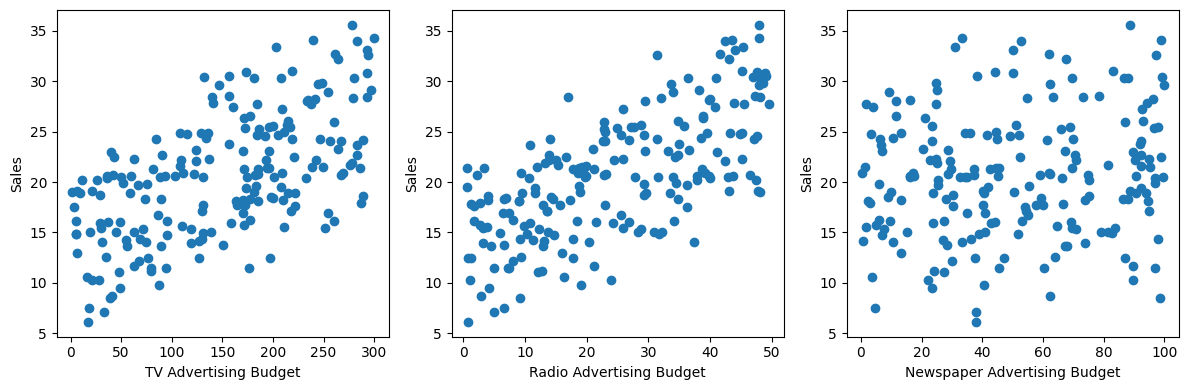

In [11]:
plt.figure(figsize=(12, 4)) # Set the figure size to accommodate three subplots

plt.subplot(1, 3 , 1) # Create the first subplot for TV vs Sales
plt.scatter(df['TV'], df['Sales']) # Create a scatter plot of TV advertising budget vs Sales
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.subplot(1, 3, 2) # Create the second subplot for Radio vs Sales
plt.scatter(df['Radio'], df['Sales']) # Create a scatter plot of Radio advertising budget vs Sales
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")

plt.subplot(1, 3 , 3) # Create the third subplot for Newspaper vs Sales
plt.scatter(df['Newspaper'], df['Sales']) # Create a scatter plot of Newspaper advertising budget vs Sales
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")

plt.tight_layout() # Adjust the layout to prevent overlap between subplots
plt.show() # Display the combined figure with all three subplots

# B. Correlation Matrix

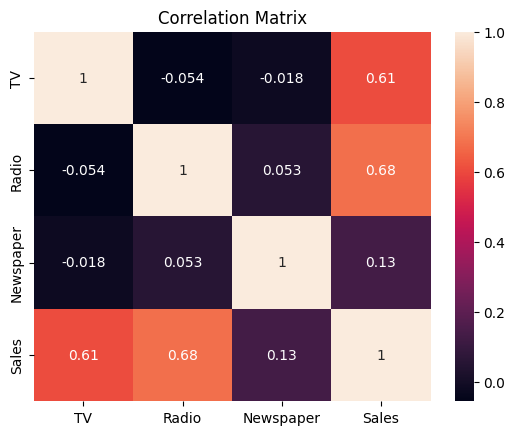

In [13]:
sns.heatmap(df.corr(), annot=True) # Create a heatmap to visualize the correlation between features and target variable
plt.title("Correlation Matrix") # Set the title of the heatmap
plt.show() # Display the heatmap

# C. Pairplot 

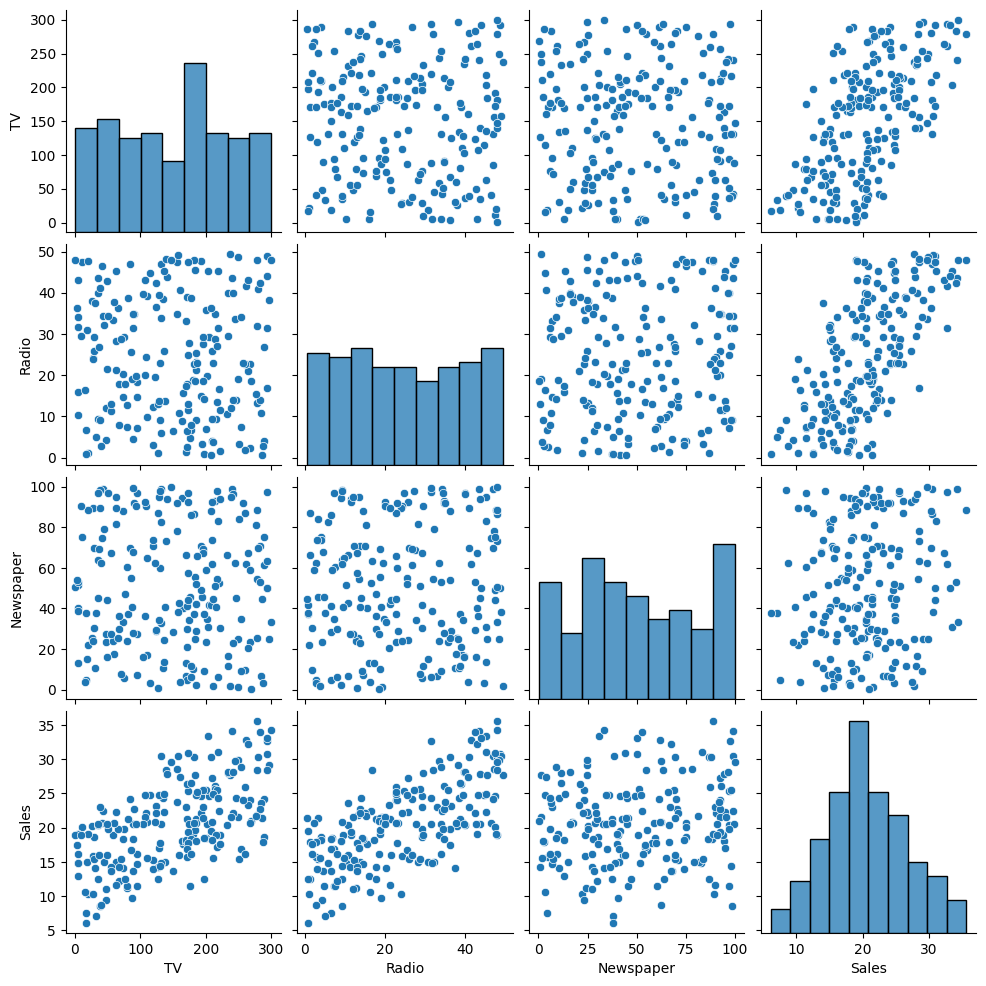

In [14]:
sns.pairplot(df) # Create a pair plot to visualize the relationships between all variables
plt.show() # Display the pair plot

# Step 4: Model Training

In [15]:
x = df[ ['TV', 'Radio', 'Newspaper'] ] # Define the feature variables (TV, Radio, Newspaper)
y = df['Sales'] # Define the target variable (Sales)

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets (80% train, 20% test)

In [17]:
model = LinearRegression() # Create an instance of the Linear Regression model
model.fit(x_train, y_train) # Fit the model to the training data, it learns the relationship between the features and the target variable


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
print("Intercept:", model.intercept_) # Print the intercept of the linear regression model

coefficients = pd.DataFrame({
    "Feature": x.columns, # Get the feature names from the columns of the feature dataset
    "Coefficient": model.coef_ # Get the coefficients of the linear regression model
})

coefficients

Intercept: 4.913713200888662


,Feature,Coefficient
0,TV,0.047147
1,Radio,0.290788
2,Newspaper,0.027958


In [19]:
y_pred = model.predict(x_test) # Use the trained model to make predictions on the test set
results = pd.DataFrame({ 
    "Actual": y_test, # Actual sales values from the test set
    "Predicted": y_pred # Predicted sales values from the model
})

results.head() # Display the first few rows of the results DataFrame to compare actual vs predicted values

,Actual,Predicted
95,14.25,11.527199
15,20.18,17.880733
30,11.20,13.023721
158,20.82,18.123569
128,18.55,18.624859


# Step 5: Performance Evaluation

In [20]:
mae = mean_absolute_error(y_test, y_pred) # Calculate Mean Absolute Error (MAE) to evaluate the model's performance
mse = mean_squared_error(y_test, y_pred) # Calculate Mean Squared Error (MSE) to evaluate the model's performance
rmse = root_mean_squared_error(y_test, y_pred) # Calculate Root Mean Squared
r2 = r2_score(y_test, y_pred) # Calculate R-squared to evaluate the model's performance

print("Mean Absolute Error (MAE):", mae) # Print the Mean Absolute Error
print("Mean Squared Error (MSE):", mse) # Print the Mean Squared
print("Root Mean Squared Error (RMSE):", rmse) # Print the Root Mean Squared Error
print("R-squared:", r2) # Print the R-squared value to indicate how well the model explains the variance in the target variable

Mean Absolute Error (MAE): 1.4382223401238339
Mean Squared Error (MSE): 3.341918319416287
Root Mean Squared Error (RMSE): 1.8280914417545657
R-squared: 0.9127352366716992


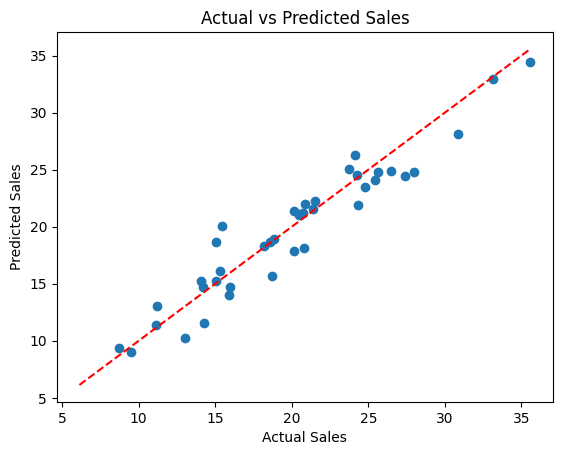

In [21]:
plt.scatter(y_test, y_pred) # Create a scatter plot of actual vs predicted values
plt.xlabel("Actual Sales") # Label the x-axis as "Actual Sales"
plt.ylabel("Predicted Sales") # Label the y-axis as "Predicted Sales"
plt.title("Actual vs Predicted Sales") # Set the title of the plot
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Add a red dashed line representing perfect predictions (where actual equals predicted)
plt.show() # Display the plot

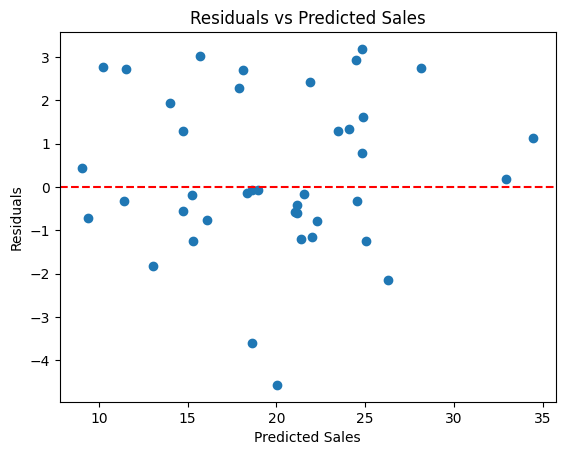

In [22]:
residuals = y_test - y_pred # Calculate the residuals (actual - predicted)
plt.scatter(y_pred, residuals) # Create a scatter plot of predicted values vs residuals
plt.axhline(0, color='red', linestyle='--') # Add a horizontal
plt.xlabel("Predicted Sales") # Label the x-axis as "Predicted Sales"
plt.ylabel("Residuals") # Label the y-axis as "Residuals"
plt.title("Residuals vs Predicted Sales") # Set the title of the plot
plt.show() # Display the plot

In [23]:
new_data = pd.DataFrame({
    "TV": [150], # New TV advertising budget value for prediction
    "Radio": [30], # New Radio advertising budget value for prediction
    "Newspaper": [20] # New Newspaper advertising budget value for prediction
})

new_prediction = model.predict(new_data) # Use the trained model to predict sales for the new data
print("Predicted Sales for new data:", new_prediction[0]) # Print the predicted sales value for the new data

Predicted Sales for new data: 21.268631967446037


In [25]:
%pip install pandas scikit-learn

import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

if "model" not in globals():
    # If the trained model is not already available in this session, train it first.
    if "df" not in globals():
        df = pd.read_csv("advertising.csv")
        df.columns = ["TV", "Radio", "Newspaper", "Sales"]
    X = df[["TV", "Radio", "Newspaper"]]
    y = df["Sales"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

export_path = "advertising_model.pkl"
with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

Note: you may need to restart the kernel to use updated packages.
Trained model exported to advertising_model.pkl



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
